In [ ]:
import pandas as pd
import quantstats as qs 
import yfinance as yf 
import bt
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("dark_background")


In [60]:
dados_empresas = pd.read_excel("statusinvest-busca-avancada.xlsx")

In [61]:
dados_empresas = dados_empresas[dados_empresas[' VALOR DE MERCADO'] > 50000000]
dados_empresas = dados_empresas[dados_empresas[' LIQUIDEZ MEDIA DIARIA'] > 1000000]
dados_empresas = dados_empresas[dados_empresas['MARG. LIQUIDA'] >= 0.05]
dados_empresas = dados_empresas[dados_empresas['MARGEM BRUTA'] >= 0.05]
dados_empresas = dados_empresas[dados_empresas['MARGEM EBIT'] >= 0.05]
dados_empresas = dados_empresas[dados_empresas['CAGR RECEITAS 5 ANOS'] >= 0.05]
dados_empresas = dados_empresas[dados_empresas['CAGR LUCROS 5 ANOS'] >= 0.05]
dados_empresas = dados_empresas[dados_empresas['ROE'] >= 0.05]
dados_empresas = dados_empresas[dados_empresas['LIQ. CORRENTE'] != 0]
dados_empresas = dados_empresas[dados_empresas[' PEG Ratio'] >= 0.05]
dados_empresas = dados_empresas[dados_empresas['P/VP'] <= 2]
dados_empresas.fillna(0, inplace=True)

In [62]:
dados_empresas['ranking_margem_liq'] = dados_empresas['MARG. LIQUIDA'].rank(ascending = False)

dados_empresas['ranking_pl'] = dados_empresas['P/L'].rank(ascending = True)

dados_empresas['ranking_psr'] = dados_empresas['PSR'].rank(ascending = False)

dados_empresas['ranking_roe'] = dados_empresas['ROE'].rank(ascending = False)

dados_empresas['ranking_p_ebit'] = dados_empresas['P/EBIT'].rank(ascending = True)

dados_empresas['ranking_lpa'] = dados_empresas[' LPA'].rank(ascending = False)

dados_empresas['ranking_liq_corr'] = dados_empresas['LIQ. CORRENTE'].rank(ascending = False)

dados_empresas['ranking_mktValue'] = dados_empresas[' VALOR DE MERCADO'].rank(ascending = False)

In [63]:
dados_empresas['ranking_final'] = dados_empresas['ranking_margem_liq'] + dados_empresas['ranking_psr'] + dados_empresas['ranking_roe'] + dados_empresas['ranking_liq_corr'] + dados_empresas['ranking_lpa'] + dados_empresas['ranking_p_ebit'] + dados_empresas['ranking_pl'] + dados_empresas['ranking_mktValue']

dados_empresas['ranking_final'] = dados_empresas['ranking_final'].rank()

In [64]:
#dados_empresas.sort_values('ranking_final').head(10)
#para mostrar as empresas selecionadas

In [65]:
dados_empresas = dados_empresas[dados_empresas['ranking_final'] <= 10]
dados_empresas = dados_empresas["TICKER"]

tickers = pd.Series(dados_empresas).tolist()
tickers = [ticker + ".SA" for ticker in tickers]

##transformando os tickers de dataframe pra lista e adicionando o SA para encontrar no yf

In [66]:

inicio = "2011-01-01"
fim = "2025-06-30"
data = yf.download(tickers, start=inicio, end=fim).dropna()
data = data["Close"]

C:\Users\adm\AppData\Local\Temp\ipykernel_14112\684146849.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=inicio, end=fim).dropna()
[*********************100%***********************]  10 of 10 completed


In [67]:
def retorno (data):
    retorno = data[-1] / data[0] -1
    return retorno 

In [68]:
simulacao = bt.get(tickers, start = inicio, end = fim)

In [69]:
pesosIguais = bt.Strategy('simulacao', [bt.algos.RunMonthly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighEqually(),
                       bt.algos.Rebalance()])

In [70]:
teste = bt.Backtest(pesosIguais, simulacao)
resultado = bt.run(teste)

100%|██████████| 1/1 [00:00<00:00,  1.92it/s]


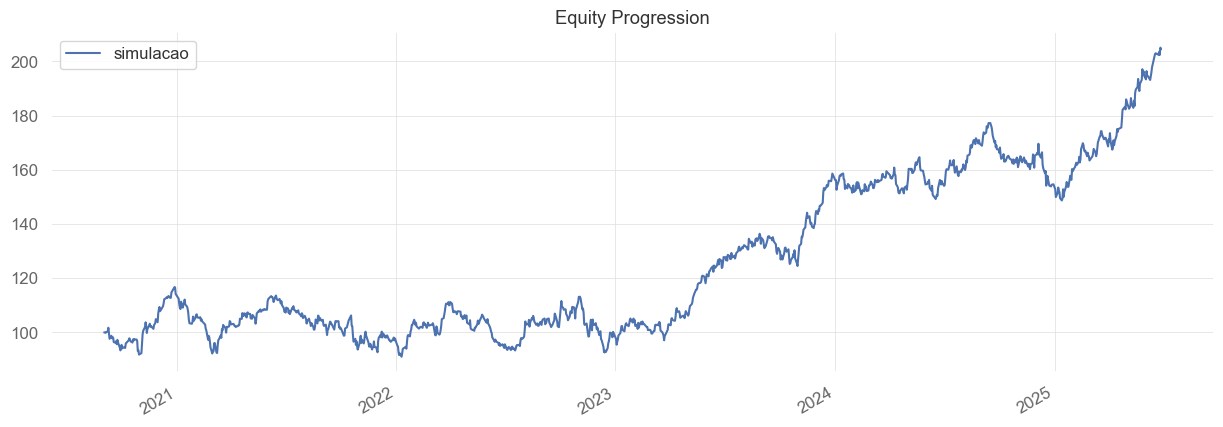

In [71]:
plt.ioff()

resultado.plot()

plt.show()

In [72]:
tickers

['CMIG4.SA',
 'CYRE3.SA',
 'ISAE4.SA',
 'ITSA4.SA',
 'LAVV3.SA',
 'SAPR11.SA',
 'SAPR3.SA',
 'SAPR4.SA',
 'TAEE11.SA',
 'VBBR3.SA']

In [73]:
##caso queira tickers unicos
##def get_base_ticker(ticker):
##    return ''.join(filter(str.isalpha, ticker))


##def get_priority(ticker):
##    if ticker.endswith('4'):
##        return 3
##    elif ticker.endswith('11'):
##        return 2
##    elif ticker.endswith('3'):
##        return 1
##    else:
##        return 0

##dados_empresas['TICKER'] = dados_empresas['TICKER'].apply(get_base_ticker)

##dados_empresas['Priority'] = dados_empresas['TICKER'].apply(get_priority)

##dados_empresas = dados_empresas.sort_values(by=['TICKER', 'Priority'], ascending=[True, False])

##dados_empresas = dados_empresas.drop_duplicates(subset='TICKER', keep='first')